# Assignment 7: Expectation-Maximization (EM)

Miranda Rasmussen <br>
11/10/2025<br>
IMT 574: Data Science II: Machine Learning<br>
Instructor: Sophin Liu

#### **Instructions**
PART 1 <br>
EM falls under unsupervised learning. But what specific kind of unsupervised learning setting would you use it for? Put differently, you could use both k-means and EM for clustering, but when will you pick EM over k-means?
##### INSTRUCTIONS
Explain in a short paragraph.

##### Part 1: When to use EM (vs. k-means)

Expectation–Maximization (EM) is a method used in unsupervised learning, which means the computer tries to find natural groupings in data without being told what those groups are. Both EM and k-means can be used for clustering, but EM is more flexible. K-means treats every group as a perfect circle and forces each item to belong to only one group. EM, on the other hand, assumes that groups can overlap and may have different shapes or spreads, more like clouds than circles. It doesn’t just say which group something belongs to, but also how strongly it belongs there, giving a probability for each group. I would use EM when the data are mixed or overlapping, when I want to understand uncertainty in group assignments, or when I want to compare different models using tools like AIC or BIC to find the best number of clusters.

#### Instructions
Part 2: EM for clustering similar countries (life-cycle savings data)

Under the life-cycle savings hypothesis, as developed by Franco Modigliani, the savings ratio (aggregate personal savings divided by disposable income) is explained by per-capita disposable income, the percentage rate of change in per-capita disposable income, and two demographic variables: The percentage of population less than 15 years old and the percentage of the population over 75 years old. The data are averaged over the decade 1960–1970 to remove the business cycle or other short-term fluctuations.

The following data was obtained from Belsley, Kuh, and Welsch (1980). They in turn obtained the data from Sterling (1977). You can download it from here. https://canvas.uw.edu/courses/1830729/files/138050612?verifier=SwxY0sshgGCIrLV9EZKHFGuBAGinxRydaS8Kolhc&wrap=1

Number - Variables <br>
I - Sr: numeric, aggregate personal savings <br>
II - pop15: numeric, % of the population under 15 <br>
III - pop75: numeric, % of the population over 75 <br>
IV - dpi: numeric, real per-capita disposable income <br>
V - ddpi: numeric, % growth rate of dpi

##### INSTRUCTIONS
1. Use EM for clustering “similar” countries.
2. Report how many groups you got and why you chose that number with the help of AIC and BIC.

In [8]:
#Import packages needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

In [9]:
#Load the life-cycle savings dataset
csv_name = "Assignment 7 data-lifecyclesaving.csv"
df = pd.read_csv(csv_name)

print("Rows, columns:", df.shape)
df.head()

Rows, columns: (50, 6)


,Contry,sr,pop15,pop75,dpi,ddpi
0,Australia,11.43,29.35,2.87,2329.68,2.87
1,Austria,12.07,23.32,4.41,1507.99,3.93
2,Belgium,13.17,23.80,4.43,2108.47,3.82
3,Bolivia,5.75,41.89,1.67,189.13,0.22
4,Brazil,12.88,42.19,0.83,728.47,4.56


In [10]:
#Variables
cols = ["sr", "pop15", "pop75", "dpi", "ddpi"]

#Keep rows with all five variables present
df_use = df[cols].dropna()
print("Rows after dropna:", df_use.shape[0])

#Standardize features before EM
scaler = StandardScaler()
X = scaler.fit_transform(df_use.values)

Rows after dropna: 50


In [11]:
#Model selection: AIC & BIC 
ks = list(range(1, 8))  # try 1..7 components
aic_list = []
bic_list = []
models = {}
random_state = 42

for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=random_state)
    gmm.fit(X)
    aic_list.append(gmm.aic(X))
    bic_list.append(gmm.bic(X))
    models[k] = gmm

sel = pd.DataFrame({"k": ks, "AIC": aic_list, "BIC": bic_list})
sel

,k,AIC,BIC
0,1,588.392263,626.632723
1,2,505.647252,584.040195
2,3,471.468230,590.013656
3,4,450.231424,608.929333
4,5,381.828600,580.678992
5,6,411.303187,650.306062
6,7,398.960747,678.116106


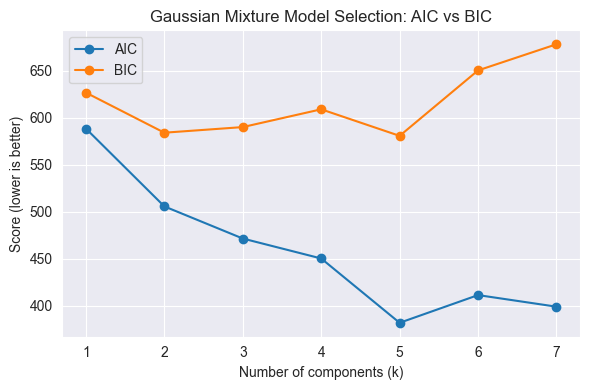

In [12]:
#Plot AIC/BIC
plt.figure(figsize=(6, 4))
plt.plot(ks, aic_list, marker="o", label="AIC")
plt.plot(ks, bic_list, marker="o", label="BIC")
plt.xlabel("Number of components (k)")
plt.ylabel("Score (lower is better)")
plt.title("Gaussian Mixture Model Selection: AIC vs BIC")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
#Choose k (BIC minimum)
best_k = int(sel.loc[sel["BIC"].idxmin(), "k"])
print("Best k by BIC:", best_k)

gmm_best = models[best_k]

#Hard labels and soft memberships
labels = gmm_best.predict(X)
proba = gmm_best.predict_proba(X)

df_clusters = df_use.copy()
df_clusters["cluster"] = labels
df_clusters.head()

Best k by BIC: 5


,sr,pop15,pop75,dpi,ddpi,cluster
0,11.43,29.35,2.87,2329.68,2.87,2
1,12.07,23.32,4.41,1507.99,3.93,2
2,13.17,23.80,4.43,2108.47,3.82,2
3,5.75,41.89,1.67,189.13,0.22,3
4,12.88,42.19,0.83,728.47,4.56,1


**Selected k = 5 by minimum BIC (and AIC)**

In [14]:
#Report cluster sizes
print("Cluster sizes:")
print(df_clusters["cluster"].value_counts().sort_index())

#Cluster means in original units
centers_scaled = gmm_best.means_
centers = pd.DataFrame(scaler.inverse_transform(centers_scaled), columns=cols)
centers["cluster"] = range(best_k)
centers

Cluster sizes:
cluster
0     2
1    10
2    23
3    13
4     2
Name: count, dtype: int64


,sr,pop15,pop75,dpi,ddpi,cluster
0,5.255000,31.080000,2.900000,1333.320000,1.500000,0
1,12.178628,42.279740,1.116844,395.452366,2.796007,1
2,12.091370,26.509907,3.465189,1911.983636,4.129168,2
3,4.286225,44.307906,1.081424,319.355809,2.686886,3
4,8.305000,42.405000,1.900000,252.025000,13.470000,4


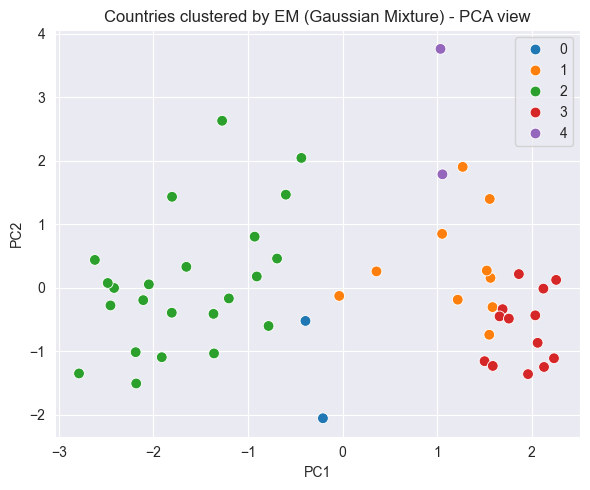

Average max membership probability: 0.996


In [15]:
#Visualization (PCA) and soft-membership confidence
pca = PCA(n_components=2, random_state=random_state)
Z = pca.fit_transform(X)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=Z[:, 0], y=Z[:, 1], hue=labels, palette="tab10", s=60)
plt.title("Countries clustered by EM (Gaussian Mixture) - PCA view")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

#Average maximum responsibility (how confident the model is)
conf = proba.max(axis=1)
print("Average max membership probability:", round(float(conf.mean()), 3))

##### Summary, Results interpretation, and impressions
The Expectation–Maximization (EM) algorithm was applied using a Gaussian Mixture Model (GMM) to identify groups of countries with similar demographic and economic characteristics based on five variables: aggregate savings rate (sr), youth population (pop15), elderly population (pop75), per-capita disposable income (dpi), and income growth rate (ddpi). After standardizing the data and evaluating models with 1 to 7 components, the optimal number of clusters was determined to be 5. This selection was made using Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC), both of which reached their lowest values at k = 5, indicating the best balance between model fit and complexity. <br><br>
The resulting five clusters represent meaningful economic groupings:
- Cluster 2 includes many mid-to-high income countries with moderate savings and balanced demographics.
- Cluster 3 groups countries with low savings and income but high youth dependency, reflecting developing economies.
- Cluster 1 shows moderate savings and a relatively young population.
- Cluster 0 contains mid-income countries with lower youth dependency.
- Cluster 4 is a small group characterized by exceptionally high income growth rates.

The average cluster membership probability of 0.996 indicates strong confidence in assignments and low overlap between groups. The PCA visualization confirmed that clusters are irregular and unevenly sized, supporting the use of EM over k-means, which assumes spherical clusters and hard assignments.<br><br>
In summary, EM successfully uncovered five distinct and interpretable country groups, using AIC and BIC as principled tools for selecting the model. This analysis illustrates the strength of the EM approach in uncovering nuanced structure within multivariate economic data where soft, probabilistic cluster boundaries provide more insight than simple distance-based partitions.

#### Conclusion

The Expectation–Maximization algorithm effectively grouped the 50 countries into five distinct clusters that capture meaningful differences in savings behavior, income, and demographic composition. By selecting the number of components through AIC and BIC, the analysis balanced model fit with interpretability and avoided overfitting. The resulting clusters showed high membership confidence and clear separation, reinforcing EM’s advantage over distance-based methods like k-means for data with irregularly shaped or overlapping clusters. Overall, this demonstrates how EM can reveal nuanced economic patterns in datasets where boundaries between groups are not sharply defined.